## Libraries import

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import string
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import random

## Directories and Image Dimensions

In [2]:
RAW_DIR = '../data/raw'
LABELS_CSV = '../data/labels.csv'
MODELS_DIR = '../models'
IMG_WIDTH = 200
IMG_HEIGHT = 60
CAPTCHA_LEN = 5
BATCH_SIZE = 32

## Complex character removal and importing images.

In [3]:
CHARSET = string.digits + string.ascii_lowercase
CHARSET = CHARSET.replace('0','').replace('o','').replace('1','').replace('l','')
NUM_CLASSES = len(CHARSET)
char_to_idx = {c: i for i, c in enumerate(CHARSET)}
idx_to_char = {i: c for i, c in enumerate(CHARSET)}

os.makedirs(MODELS_DIR, exist_ok=True)

In [4]:
df = pd.read_csv(LABELS_CSV)
images = []
labels = []

def load_image(path):
    img = Image.open(path).convert('L')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr[..., np.newaxis]

for _, row in df.iterrows():
    txt = str(row['label'])
    if len(txt) != CAPTCHA_LEN:
        continue
    if not all(c in char_to_idx for c in txt):
        continue
    try:
        img = load_image(os.path.join(RAW_DIR, row['filename']))
        images.append(img)
        labels.append([char_to_idx[c] for c in txt])
    except Exception:
        pass

X = np.array(images)
Y = np.array(labels)

print(f'Loaded {len(X)} examples, shape {X.shape}')

Loaded 100000 examples, shape (100000, 60, 200, 1)


## EDA

Character split by position

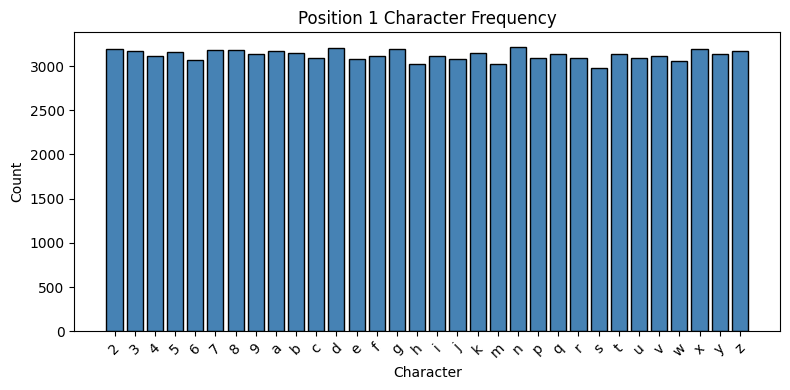

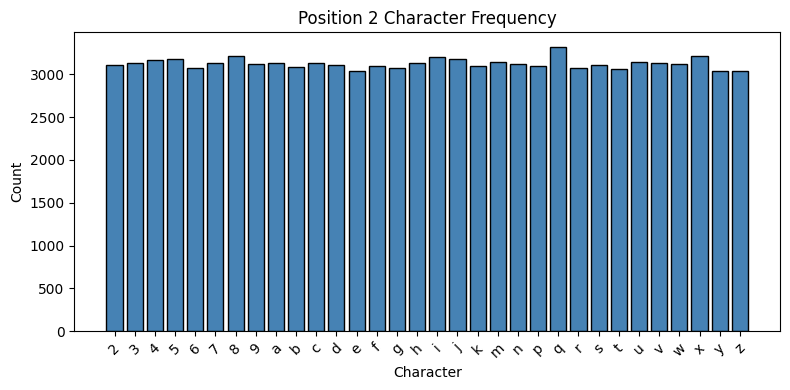

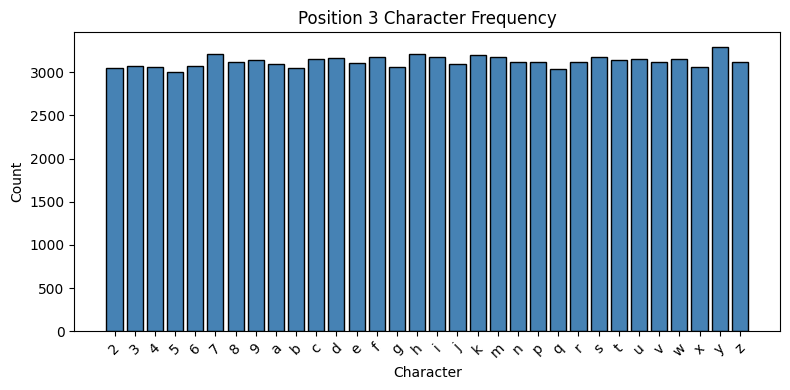

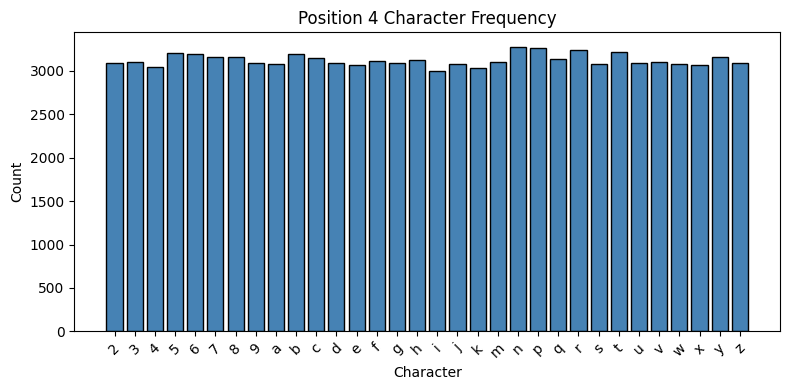

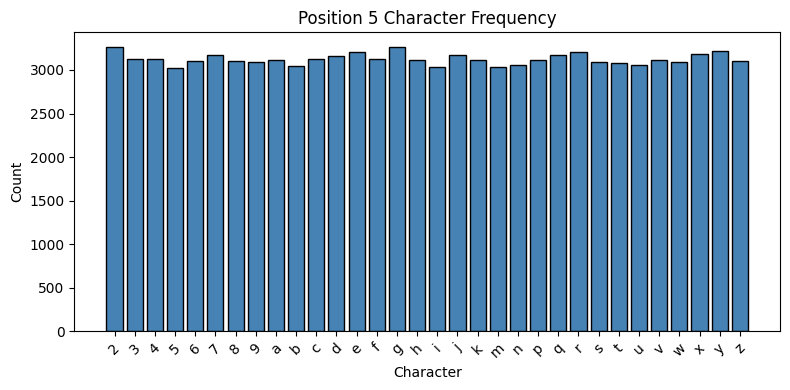

In [5]:
for pos in range(CAPTCHA_LEN):
       counts = Counter(Y[:, pos])
       chars = sorted(counts.keys())
       freqs = [counts[c] for c in chars]
       plt.figure(figsize=(8, 4))
       plt.bar([idx_to_char[c] for c in chars], freqs, color='steelblue', edgecolor='black')
       plt.title(f'Position {pos+1} Character Frequency')
       plt.ylabel('Count'); plt.xlabel('Character')
       plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Duplicate check

In [6]:
# Check for duplicate labels
label_strings = [''.join(idx_to_char[i] for i in row) for row in Y]
unique_labels = set(label_strings)
print(f'Total labels: {len(label_strings)}')
print(f'Unique labels: {len(unique_labels)}')
if len(unique_labels) < len(label_strings):
    print(' duplicate label exists')
    counts = Counter(label_strings)
    duplicates = [l for l, c in counts.items() if c > 1]
    print(f'Eg: {set(duplicates[:5])}')
else:
    print(' All labels unique.')


Total labels: 100000
Unique labels: 99850
 duplicate label exists
Eg: {'8tiva', '5b5ys', 'pubw6', 'iwg2s', 'ru8z7'}


## Data split for training & Data encoding

In [7]:
# split the data
idx = np.arange(len(X))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=1)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=1)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
Y_train, Y_val, Y_test = Y[train_idx], Y[val_idx], Y[test_idx]

def to_onehot(Y):
    return [keras.utils.to_categorical(Y[:, i], NUM_CLASSES)
            for i in range(CAPTCHA_LEN)]

Y_train_oh = to_onehot(Y_train)
Y_val_oh   = to_onehot(Y_val)
Y_test_oh  = to_onehot(Y_test)

print('train/val/test:',
      len(X_train), len(X_val), len(X_test))

train/val/test: 80000 10000 10000


## CNN trained via Image slicing.

In [8]:
# build a CNN with spatial slices so each head only sees its own region
def build_model():
    inp = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    # feature map now roughly (batch, H/8, W/8, 128)

    # split width into CAPTCHA_LEN pieces and give each head its slice
    feature_w = IMG_WIDTH // 8
    slice_w = feature_w // CAPTCHA_LEN

    outputs = []
    for i in range(CAPTCHA_LEN):
        start = i * slice_w
        end = start + slice_w if i < CAPTCHA_LEN - 1 else feature_w
        char_feat = x[:, :, start:end, :]
        char_feat = layers.GlobalAveragePooling2D()(char_feat)
        char_feat = layers.Dense(64, activation='relu')(char_feat)
        out = layers.Dense(NUM_CLASSES, activation='softmax', name=f'char_{i}')(char_feat)
        outputs.append(out)
    return keras.Model(inputs=inp, outputs=outputs)

model = build_model()
model.compile(optimizer='adam',
              loss=['categorical_crossentropy'] * CAPTCHA_LEN,
              metrics=['accuracy'] * CAPTCHA_LEN)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 200,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 60, 200,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 30, 100,   │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 30, 100,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 15, 50,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 50,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 7, 25,     │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 7, 5, 128) │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 7, 5, 128) │          0 │ max_pooling2d_2[… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 7, 5, 128) │          0 │ max_pooling2d_2[… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 7, 5, 128) │          0 │ max_pooling2d_2[… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 7, 5, 128) │          0 │ max_pooling2d_2[… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ get_item[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ get_item_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ get_item_2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ get_item_3[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ get_item_4[0][0]  │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 144,352 (563.88 KB)

 Trainable params: 144,352 (563.88 KB)

 Non-trainable params: 0 (0.00 B)

Training the model and callbacks, could take 15mins or more depending on the hardware and environment ran on.

In [9]:
# train
callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(MODELS_DIR, 'captcha_model.keras'),
        save_best_only=True, monitor='val_loss'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, Y_train_oh,
    validation_data=(X_val, Y_val_oh),
    epochs=20,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 61s 24ms/step - char_0_accuracy: 0.5937 - char_0_loss: 1.2648 - char_1_accuracy: 0.5853 - char_1_loss: 1.2909 - char_2_accuracy: 0.5903 - char_2_loss: 1.2757 - char_3_accuracy: 0.6001 - char_3_loss: 1.2469 - char_4_accuracy: 0.5934 - char_4_loss: 1.2646 - loss: 6.3429 - val_char_0_accuracy: 0.8852 - val_char_0_loss: 0.3559 - val_char_1_accuracy: 0.8903 - val_char_1_loss: 0.3529 - val_char_2_accuracy: 0.8845 - val_char_2_loss: 0.3713 - val_char_3_accuracy: 0.8990 - val_char_3_loss: 0.3206 - val_char_4_accuracy: 0.8949 - val_char_4_loss: 0.3564 - val_loss: 1.7571
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 58s 23ms/step - char_0_accuracy: 0.9364 - char_0_loss: 0.2075 - char_1_accuracy: 0.9351 - char_1_loss: 0.2105 - char_2_accuracy: 0.9370 - char_2_loss: 0.2065 - char_3_accuracy: 0.9368 - char_3_loss: 0.2044 - char_4_accuracy: 0.9353 - char_4_loss: 0.2095 - loss: 1.0384 - val_char_0_accuracy: 0.9674 - val_char_0_loss: 0.1152 - val_char_1_accuracy: 

## Model Evaluation

In [10]:
# evaluate
model = keras.models.load_model(os.path.join(MODELS_DIR, 'captcha_model.keras'))
preds = model.predict(X_test, batch_size=BATCH_SIZE)

preds_idx = np.stack([np.argmax(p, axis=1) for p in preds], axis=1)
pred_str = [''.join(idx_to_char[i] for i in row) for row in preds_idx]
true_str = [''.join(idx_to_char[i] for i in row) for row in Y_test]

correct = sum(p == t for p, t in zip(pred_str, true_str))
print('Sequence accuracy:', correct / len(true_str))

for i in range(10):
    print('T', true_str[i], 'P', pred_str[i])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Sequence accuracy: 0.9918
T kkqsb P kkqsb
T zjgaw P zjgaw
T dqccb P dqccb
T 8vsvw P 8vsvw
T n663b P n663b
T dunqz P dunqz
T i5unx P i5unx
T rwnnr P rwnnr
T cm9da P cm9da
T nhvzt P nhvzt


per-character accuracy at each position

In [11]:

print('PER-CHARACTER ACCURACY BY POSITION')


for pos in range(CAPTCHA_LEN):
    true_chars = Y_test[:, pos]
    pred_chars = preds_idx[:, pos]
    
    char_accs = {}
    for char_id in range(NUM_CLASSES):
        mask = true_chars == char_id
        if mask.sum() == 0:
            continue
        acc = (pred_chars[mask] == char_id).sum() / mask.sum() * 100
        char_accs[idx_to_char[char_id]] = acc
    
    # sort by accuracy
    sorted_chars = sorted(char_accs.items(), key=lambda x: x[1])
    
    print(f'\nPosition {pos+1}:')
    print(f'  Worst performers:')
    for ch, acc in sorted_chars[:3]:
        print(f'    "{ch}": {acc:.1f}%')
    print(f'  Best performers:')
    for ch, acc in sorted_chars[-3:]:
        print(f'    "{ch}": {acc:.1f}%')
    
    # overall position accuracy
    pos_acc = (pred_chars == true_chars).sum() / len(true_chars) * 100
    print(f'  Overall: {pos_acc:.1f}%')


PER-CHARACTER ACCURACY BY POSITION

Position 1:
  Worst performers:
    "h": 98.8%
    "r": 99.0%
    "y": 99.3%
  Best performers:
    "t": 100.0%
    "w": 100.0%
    "z": 100.0%
  Overall: 99.8%

Position 2:
  Worst performers:
    "h": 98.8%
    "8": 99.0%
    "f": 99.1%
  Best performers:
    "x": 100.0%
    "y": 100.0%
    "z": 100.0%
  Overall: 99.9%

Position 3:
  Worst performers:
    "n": 98.1%
    "p": 99.4%
    "d": 99.4%
  Best performers:
    "x": 100.0%
    "y": 100.0%
    "z": 100.0%
  Overall: 99.8%

Position 4:
  Worst performers:
    "j": 98.6%
    "h": 98.8%
    "9": 99.7%
  Best performers:
    "x": 100.0%
    "y": 100.0%
    "z": 100.0%
  Overall: 99.9%

Position 5:
  Worst performers:
    "j": 98.2%
    "a": 99.0%
    "i": 99.4%
  Best performers:
    "w": 100.0%
    "x": 100.0%
    "z": 100.0%
  Overall: 99.8%


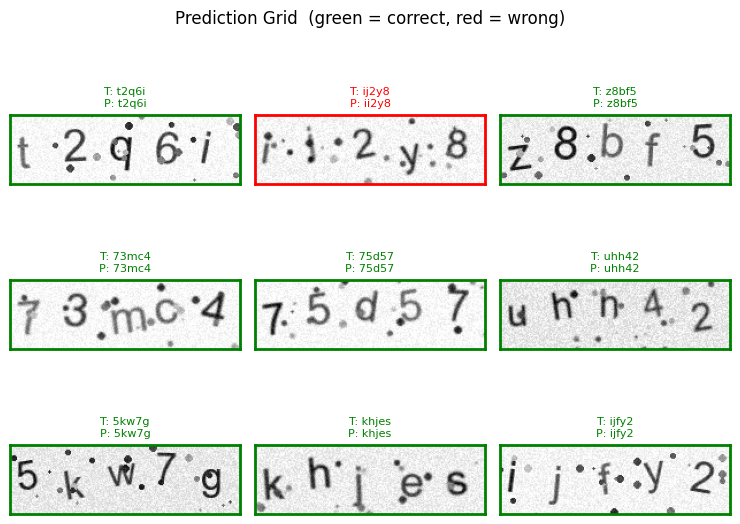

In [12]:
n_rows, n_cols = 3, 3
sample_idx = random.sample(range(len(X_test)), n_rows * n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2))

for ax, idx in zip(axes.flat, sample_idx):
    img = X_test[idx].squeeze()
    true  = true_str[idx]
    pred  = pred_str[idx]
    correct = (true == pred)

    ax.imshow(img, cmap='gray')
    ax.set_title(f'T: {true}\nP: {pred}',
                 color='green' if correct else 'red', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('green' if correct else 'red')
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Prediction Grid  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.show()